# Curva de pH en una disolución tampón

Una disolución tampón resiste cambios de pH porque contiene un ácido débil y su base conjugada. La relación de Henderson-Hasselbalch se usa para estimar el pH cuando se conoce la relación entre ambas formas {cite:p}`iupac_goldbook_henderson_hasselbalch`.

Este ejemplo usa el par ácido acético/acetato y calcula el pH al añadir ácido o base fuerte:

$$
pH = pK_a + \log_{10}\left(\frac{n_{\mathrm{A^-}}}{n_{\mathrm{HA}}}\right)
$$

```{admonition} Qué puedes modificar
:class: dropdown
Cambia `n_HA0`, `n_A0` o el intervalo de `additions`. La zona $pK_a \pm 1$ suele ser la región donde el tampón responde de forma más gradual.
```


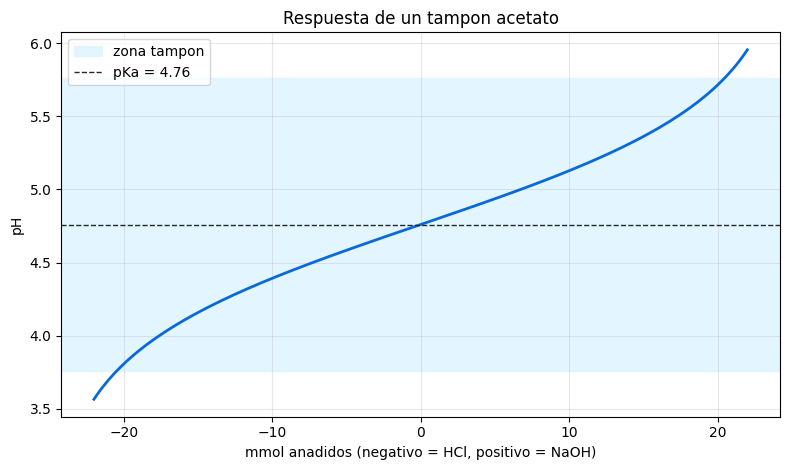

Initial pH = 4.76
pH after adding 10 mmol NaOH = 5.13
pH after adding 10 mmol HCl  = 4.39


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Editable parameters
pKa = 4.76
n_HA0 = 25.0  # mmol acetic acid
n_A0 = 25.0   # mmol acetate
additions = np.linspace(-22, 22, 220)  # negative: strong acid; positive: strong base

pH = []
for added in additions:
    if added >= 0:
        n_HA = n_HA0 - added
        n_A = n_A0 + added
    else:
        n_HA = n_HA0 - added
        n_A = n_A0 + added
    n_HA = max(n_HA, 1e-6)
    n_A = max(n_A, 1e-6)
    pH.append(pKa + np.log10(n_A / n_HA))
pH = np.array(pH)

plt.figure(figsize=(8, 4.8))
plt.plot(additions, pH, linewidth=2, color="#0969da")
plt.axhspan(pKa - 1, pKa + 1, color="#ddf4ff", alpha=0.8, label="zona tampon")
plt.axhline(pKa, color="#24292f", linestyle="--", linewidth=1, label=f"pKa = {pKa}")
plt.xlabel("mmol anadidos (negativo = HCl, positivo = NaOH)")
plt.ylabel("pH")
plt.title("Respuesta de un tampon acetato")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Initial pH = {pKa + np.log10(n_A0/n_HA0):.2f}")
print(f"pH after adding 10 mmol NaOH = {pH[np.argmin(np.abs(additions - 10))]:.2f}")
print(f"pH after adding 10 mmol HCl  = {pH[np.argmin(np.abs(additions + 10))]:.2f}")


## Interpretación

La zona más estable aparece cuando ácido y base conjugada tienen cantidades comparables. Cerca de los extremos, una de las dos formas se agota y el pH cambia con mucha más rapidez.

```{admonition} Lectura guiada
:class: dropdown
Localiza la banda azul. Dentro de esa banda, una misma cantidad añadida de HCl o NaOH produce un cambio de pH menor que fuera de ella. Esa es la idea práctica de capacidad amortiguadora.
```
